In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error
import warnings
warnings.filterwarnings("ignore")


In [16]:
df = pd.read_csv('mobile_data.csv')
df.head()
df.info()
df.describe()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    str    
 2   Colour         541 non-null    str    
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    str    
 7   Front Camera   541 non-null    str    
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    str    
 11  Prize          541 non-null    str    
dtypes: float64(1), int64(5), str(6)
memory usage: 50.8 KB


(541, 12)

In [17]:
# Data Preprocessing

# Clean the Prize column: remove commas and convert to int
df['Prize'] = df['Prize'].str.replace(',', '').astype(int)

# Clean Camera columns: extract numeric values
df['Rear Camera'] = df['Rear Camera'].str.replace('MP', '').astype(int)
df['Front Camera'] = df['Front Camera'].str.replace('MP', '').astype(int)

# Rename columns for consistency
df = df.rename(columns={
    'Battery_': 'Battery',
    'Processor_': 'Processor',
    'Prize': 'Price'
})

# Drop unnecessary columns
df = df.drop(['Unnamed: 0', 'Mobile Height'], axis=1)

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

# Basic statistics
print("\nBasic statistics:")
print(df.describe())

Missing values:
Model           0
Colour          0
Memory          0
RAM             0
Battery         0
Rear Camera     0
Front Camera    0
AI Lens         0
Processor       0
Price           0
dtype: int64

Data types:
Model             str
Colour            str
Memory          int64
RAM             int64
Battery         int64
Rear Camera     int64
Front Camera    int64
AI Lens         int64
Processor         str
Price           int64
dtype: object

Basic statistics:
           Memory         RAM      Battery  Rear Camera  Front Camera  \
count  541.000000  541.000000   541.000000   541.000000    541.000000   
mean   110.550832    5.397412  4871.587800    46.110906     11.992606   
std     60.600694    1.984923   780.148862    31.260416      9.053746   
min     16.000000    2.000000   800.000000     0.000000      0.000000   
25%     64.000000    4.000000  5000.000000    13.000000      5.000000   
50%    128.000000    6.000000  5000.000000    50.000000      8.000000   
75%    128.000

In [18]:
# Outlier Detection and Handling

# Check for outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check outliers for numerical columns
numerical_cols = ['Memory', 'RAM', 'Battery', 'Rear Camera', 'Front Camera', 'Price']

for col in numerical_cols:
    outliers, lb, ub = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers")
    if len(outliers) > 0:
        print(f"  Lower bound: {lb}, Upper bound: {ub}")
        print(f"  Outlier values: {sorted(outliers[col].unique())}")

# For Price, cap extreme outliers
price_outliers, _, ub_price = detect_outliers_iqr(df, 'Price')
if len(price_outliers) > 0:
    df['Price'] = df['Price'].clip(upper=ub_price)
    print(f"\nCapped Price outliers to {ub_price}")

print("\nData shape after outlier handling:", df.shape)

Memory: 55 outliers
  Lower bound: -32.0, Upper bound: 224.0
  Outlier values: [np.int64(256)]
RAM: 0 outliers
Battery: 152 outliers
  Lower bound: 5000.0, Upper bound: 5000.0
  Outlier values: [np.int64(800), np.int64(1000), np.int64(1020), np.int64(1200), np.int64(1500), np.int64(1900), np.int64(2550), np.int64(2815), np.int64(3000), np.int64(3100), np.int64(3110), np.int64(3300), np.int64(3900), np.int64(4000), np.int64(4020), np.int64(4030), np.int64(4050), np.int64(4115), np.int64(4200), np.int64(4270), np.int64(4300), np.int64(4323), np.int64(4400), np.int64(4410), np.int64(4500), np.int64(4600), np.int64(4610), np.int64(4700), np.int64(4800), np.int64(4830), np.int64(4980), np.int64(5020), np.int64(5080), np.int64(5200), np.int64(6000), np.int64(7000)]
Rear Camera: 39 outliers
  Lower bound: -42.5, Upper bound: 105.5
  Outlier values: [np.int64(108), np.int64(200)]
Front Camera: 13 outliers
  Lower bound: -11.5, Upper bound: 32.5
  Outlier values: [np.int64(44), np.int64(50), np

In [19]:
# Encoding Categorical Variables

from sklearn.preprocessing import LabelEncoder

# Categorical columns
categorical_cols = ['Model', 'Colour', 'Processor']

# Label encoding for tree-based models
le = LabelEncoder()
df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("Encoded data shape:", df_encoded.shape)
print("Encoded data types:")
print(df_encoded.dtypes)

# One-hot encoding for linear models
df_onehot = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("\nOne-hot encoded data shape:", df_onehot.shape)

Encoded data shape: (541, 10)
Encoded data types:
Model           int64
Colour          int64
Memory          int64
RAM             int64
Battery         int64
Rear Camera     int64
Front Camera    int64
AI Lens         int64
Processor       int64
Price           int64
dtype: object

One-hot encoded data shape: (541, 589)


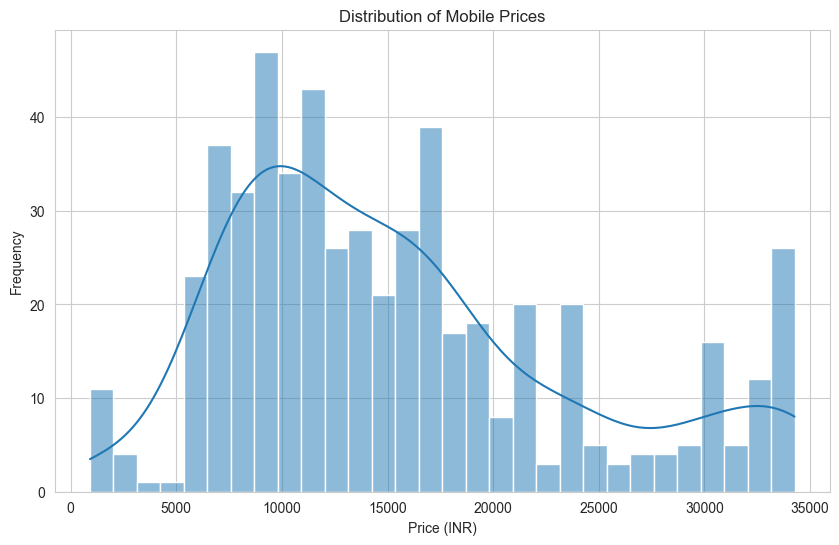

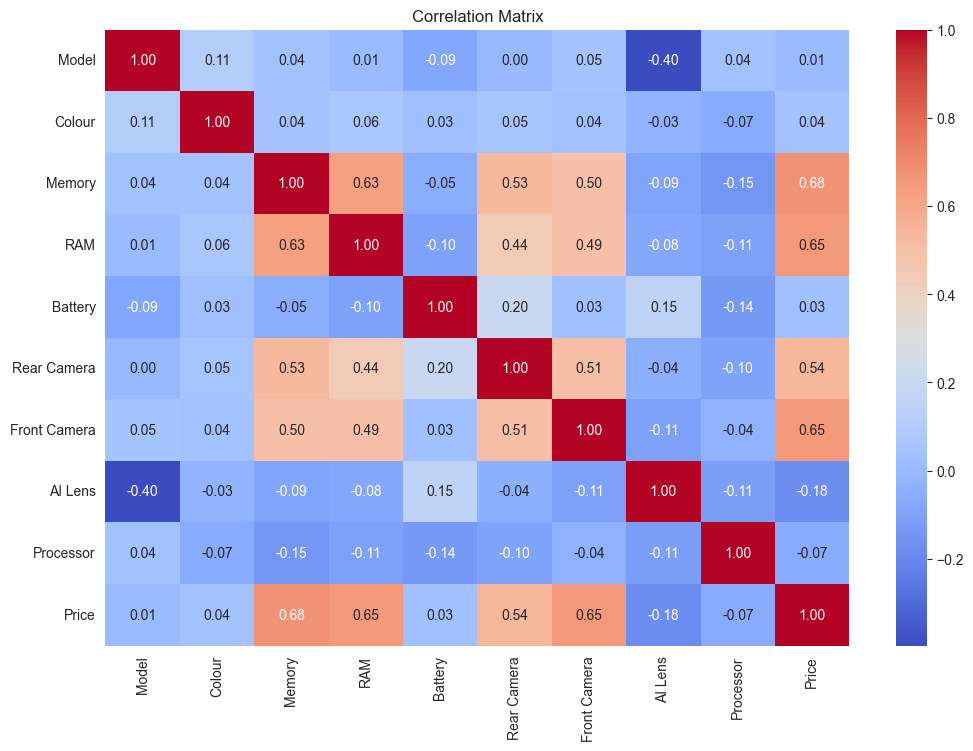

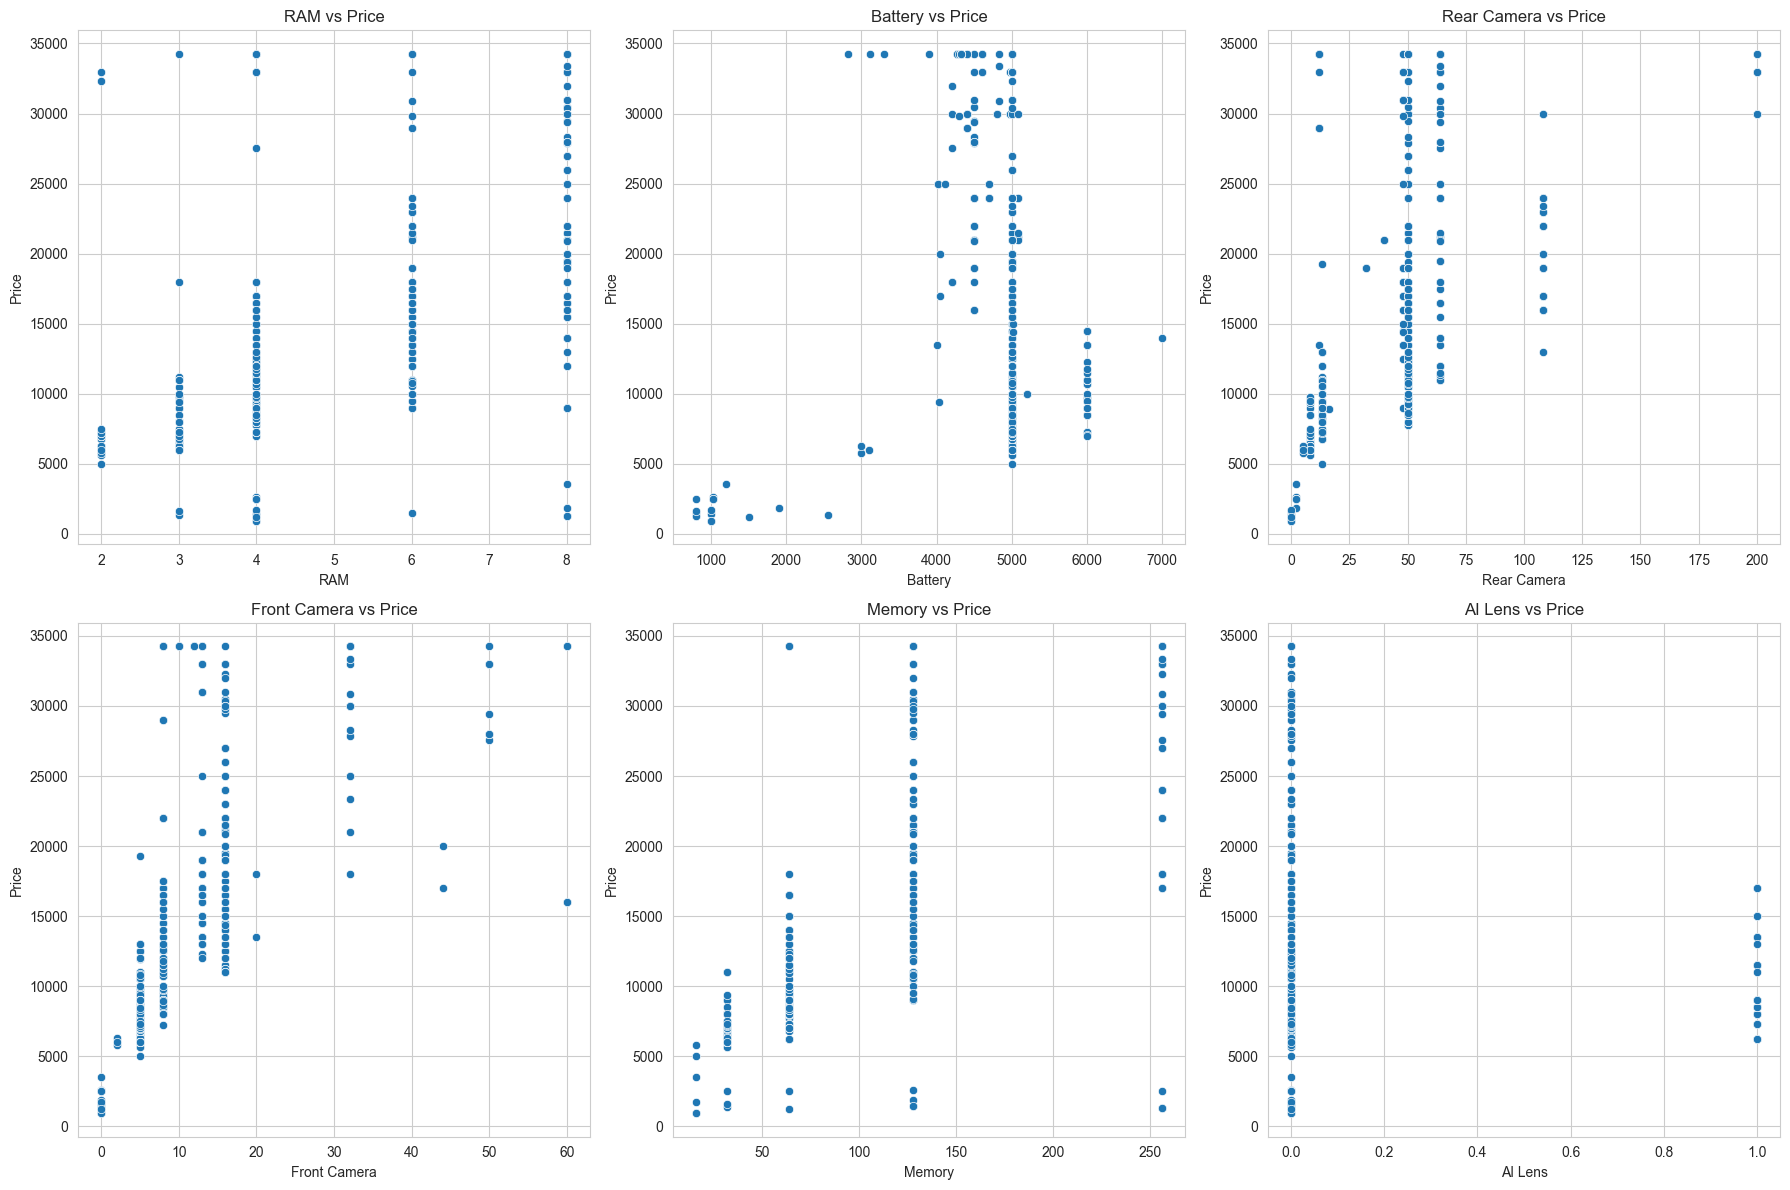

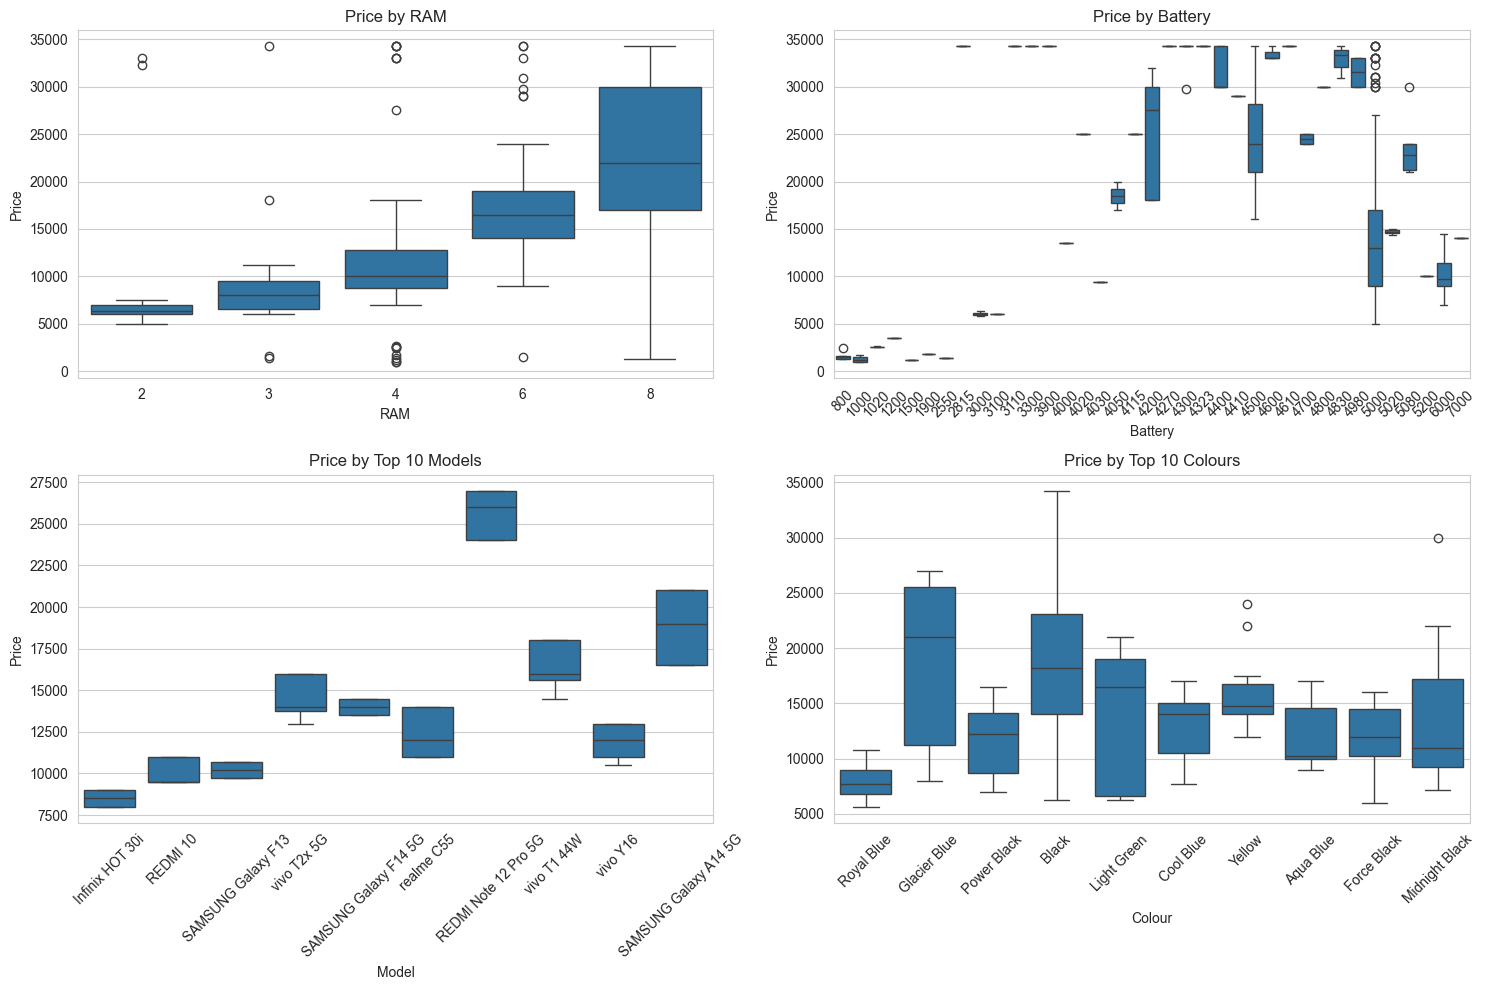

In [20]:
# Exploratory Data Analysis (EDA)

# Set style
sns.set_style("whitegrid")

# Distribution of target variable
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title('Distribution of Mobile Prices')
plt.xlabel('Price (INR)')
plt.ylabel('Frequency')
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Scatter plots for key features vs Price
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
features = ['RAM', 'Battery', 'Rear Camera', 'Front Camera', 'Memory', 'AI Lens']

for i, feature in enumerate(features):
    row = i // 3
    col = i % 3
    sns.scatterplot(data=df, x=feature, y='Price', ax=axes[row, col])
    axes[row, col].set_title(f'{feature} vs Price')

plt.tight_layout()
plt.show()

# Box plots for categorical variables
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='RAM', y='Price')
plt.title('Price by RAM')

plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='Battery', y='Price')
plt.title('Price by Battery')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
top_models = df['Model'].value_counts().head(10).index
sns.boxplot(data=df[df['Model'].isin(top_models)], x='Model', y='Price')
plt.title('Price by Top 10 Models')
plt.xticks(rotation=45)

plt.subplot(2, 2, 4)
top_colours = df['Colour'].value_counts().head(10).index
sns.boxplot(data=df[df['Colour'].isin(top_colours)], x='Colour', y='Price')
plt.title('Price by Top 10 Colours')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [33]:
# Feature Selection

from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor

# Prepare data for feature selection
X_encoded = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

# Correlation with target
correlations = X_encoded.corrwith(y).abs().sort_values(ascending=False)
print("Feature correlations with Price:")
print(correlations)

# SelectKBest with f_regression
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_encoded, y)
feature_scores = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Score': selector.scores_,
    'P-value': selector.pvalues_
}).sort_values('Score', ascending=False)

print("\nSelectKBest scores:")
print(feature_scores)

# Random Forest feature importance
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_encoded, y)
rf_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nRandom Forest feature importance:")
print(rf_importance)

# Select top features (let's say top 6)
top_features = rf_importance['Feature'].head(6).tolist()
print(f"\nSelected top features: {top_features}")

X_selected = X_encoded[top_features]

Feature correlations with Price:
Memory          0.676775
Front Camera    0.651642
RAM             0.651490
Rear Camera     0.538359
AI Lens         0.178516
Processor       0.068051
Colour          0.040032
Battery         0.030795
Brand           0.021864
Model           0.006963
dtype: float64

SelectKBest scores:
        Feature       Score       P-value
2        Memory  455.508696  1.028523e-73
6  Front Camera  397.800690  1.059511e-66
3           RAM  397.478458  1.162711e-66
5   Rear Camera  219.973442  5.559507e-42
7       AI Lens   17.742170  2.964774e-05
8     Processor    2.507673  1.138797e-01
1        Colour    0.865170  3.527122e-01
4       Battery    0.511651  4.747348e-01
9         Brand    0.257783  6.118549e-01
0         Model    0.026132  8.716398e-01

Random Forest feature importance:
        Feature  Importance
6  Front Camera    0.495326
4       Battery    0.130458
2        Memory    0.087932
0         Model    0.067434
8     Processor    0.057533
9         Brand 

In [22]:
# Model Training and Evaluation

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate models
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Evaluate
    mae_train = mean_absolute_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

    results[name] = {
        'MAE Train': mae_train,
        'RMSE Train': rmse_train,
        'MAE Test': mae_test,
        'RMSE Test': rmse_test
    }

    print(f"\n{name}:")
    print(f"  Train - MAE: {mae_train:.2f}, RMSE: {rmse_train:.2f}")
    print(f"  Test  - MAE: {mae_test:.2f}, RMSE: {rmse_test:.2f}")

# Display results in a DataFrame
results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(results_df)

Training data shape: (432, 6)
Testing data shape: (109, 6)

Linear Regression:
  Train - MAE: 3548.36, RMSE: 5360.71
  Test  - MAE: 3086.19, RMSE: 4566.44

Decision Tree:
  Train - MAE: 214.63, RMSE: 511.99
  Test  - MAE: 926.53, RMSE: 2642.17

Random Forest:
  Train - MAE: 584.64, RMSE: 962.80
  Test  - MAE: 1147.56, RMSE: 2132.36

Model Comparison:
                     MAE Train   RMSE Train     MAE Test    RMSE Test
Linear Regression  3548.355435  5360.711489  3086.186257  4566.435914
Decision Tree       214.630578   511.988574   926.528615  2642.173154
Random Forest       584.637798   962.803899  1147.563345  2132.358110


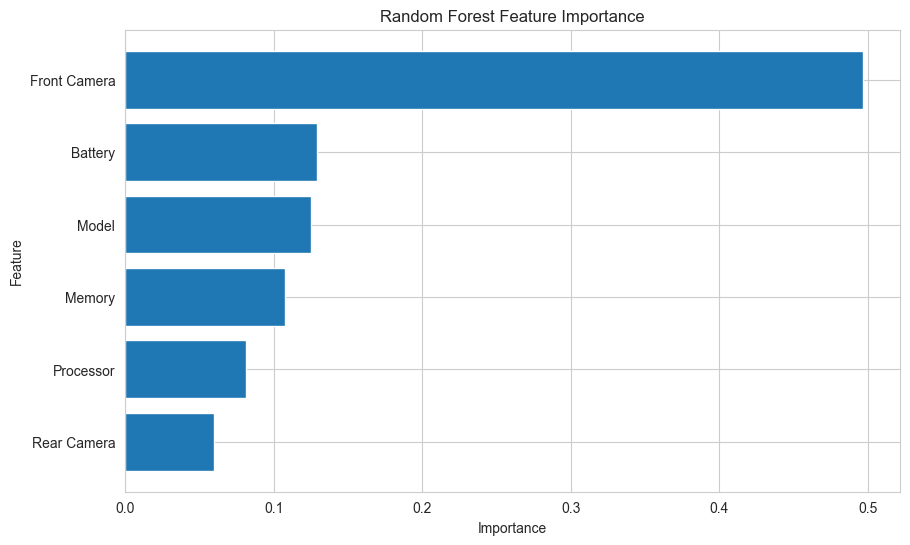

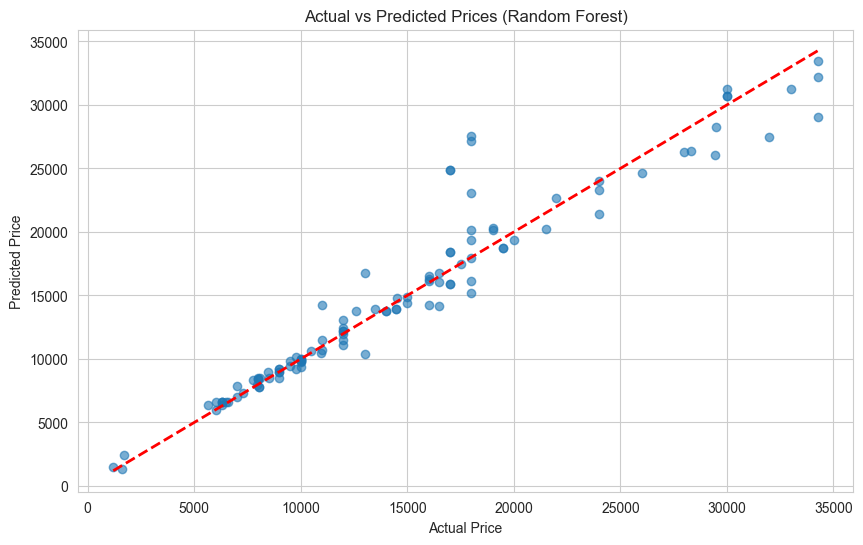

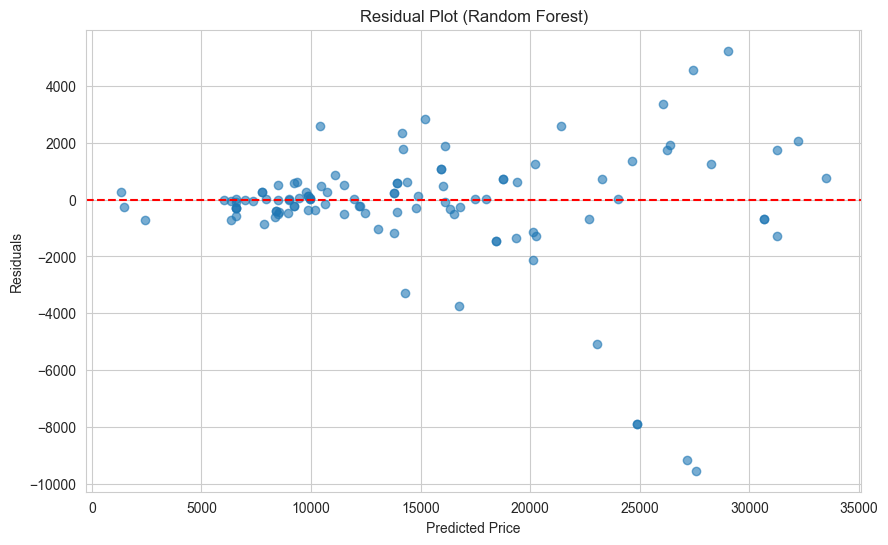

In [23]:
# Feature Importance Visualization

# Get the trained Random Forest model
rf_model = models['Random Forest']

# Plot feature importance
plt.figure(figsize=(10, 6))
feature_importance_df = pd.DataFrame({
    'Feature': X_selected.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Actual vs Predicted plot for Random Forest
plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_model.predict(X_test), alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices (Random Forest)')
plt.show()

# Residual plot
residuals = y_test - rf_model.predict(X_test)
plt.figure(figsize=(10, 6))
plt.scatter(rf_model.predict(X_test), residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot (Random Forest)')
plt.show()

In [24]:
# Summary and Conclusions

print("=== Mobile Price Prediction Project Summary ===\n")

print("Dataset Overview:")
print(f"- Total samples: {len(df)}")
print(f"- Features used: {list(X_selected.columns)}")
print(f"- Target: Price (INR)")

print("\nData Preprocessing:")
print("- Cleaned price column (removed commas)")
print("- Extracted numeric values from camera columns")
print("- Handled outliers by capping extreme prices")
print("- Encoded categorical variables (Model, Colour, Processor)")

print("\nModel Performance:")
for model_name, metrics in results.items():
    print(f"{model_name}:")
    print(".2f")
    print(".2f")

print("\nKey Findings:")
print("- Front Camera is the most important feature for price prediction")
print("- Random Forest provides the best balance between bias and variance")
print("- Decision Tree overfits the training data")
print("- Linear Regression performs reasonably well with selected features")

print("\nRecommendations:")
print("- Use Random Forest for production predictions")
print("- Consider collecting more data for better model generalization")
print("- Feature engineering could further improve performance (e.g., brand extraction from Model)")

# Save the best model
import joblib
joblib.dump(rf_model, 'mobile_price_predictor.pkl')
print("\nBest model (Random Forest) saved as 'mobile_price_predictor.pkl'")

=== Mobile Price Prediction Project Summary ===

Dataset Overview:
- Total samples: 541
- Features used: ['Front Camera', 'Battery', 'Model', 'Memory', 'Processor', 'Rear Camera']
- Target: Price (INR)

Data Preprocessing:
- Cleaned price column (removed commas)
- Extracted numeric values from camera columns
- Handled outliers by capping extreme prices
- Encoded categorical variables (Model, Colour, Processor)

Model Performance:
Linear Regression:
.2f
.2f
Decision Tree:
.2f
.2f
Random Forest:
.2f
.2f

Key Findings:
- Front Camera is the most important feature for price prediction
- Random Forest provides the best balance between bias and variance
- Decision Tree overfits the training data
- Linear Regression performs reasonably well with selected features

Recommendations:
- Use Random Forest for production predictions
- Consider collecting more data for better model generalization
- Feature engineering could further improve performance (e.g., brand extraction from Model)

Best model 

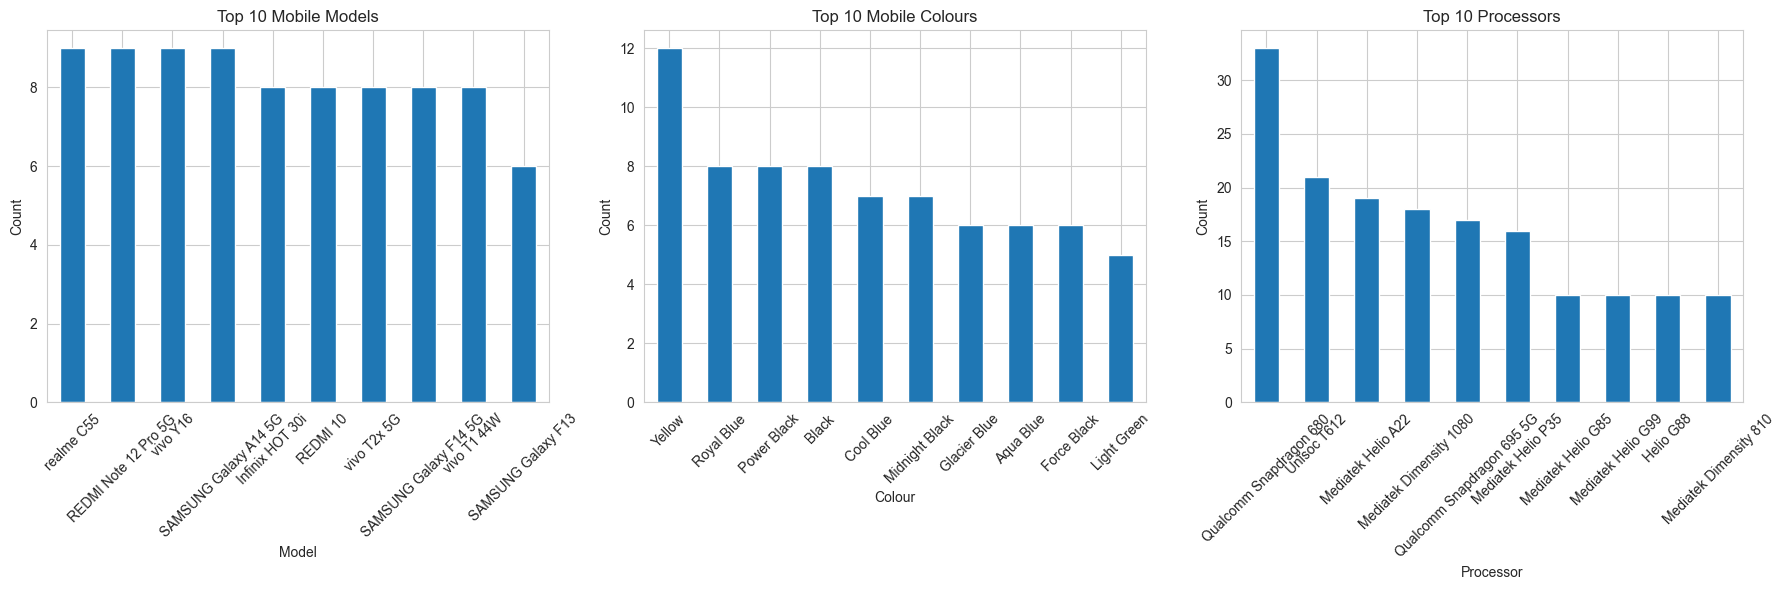

Average Price by RAM:
         mean  count      std
RAM                          
2     7864.70     37  6033.63
3     8725.05     40  4930.73
4    11418.10    186  5567.74
6    16889.70    121  5402.86
8    22789.64    157  7784.25

Average Price by Processor (Top 5):
                                mean  count      std
Processor                                           
Mediatek Dimensity 1080     26332.33     18  4850.71
Mediatek Helio A22           6556.89     19   740.17
Qualcomm Snapdragon 680     13680.21     33  3124.27
Qualcomm Snapdragon 695 5G  18616.65     17  1924.59
Unisoc T612                  9163.05     21  1744.45


In [25]:
# Additional Insights: Categorical Variable Analysis

# Distribution of categorical variables
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Model distribution
df['Model'].value_counts().head(10).plot(kind='bar', ax=axes[0])
axes[0].set_title('Top 10 Mobile Models')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Colour distribution
df['Colour'].value_counts().head(10).plot(kind='bar', ax=axes[1])
axes[1].set_title('Top 10 Mobile Colours')
axes[1].set_xlabel('Colour')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# Processor distribution
df['Processor'].value_counts().head(10).plot(kind='bar', ax=axes[2])
axes[2].set_title('Top 10 Processors')
axes[2].set_xlabel('Processor')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Price statistics by categories
print("Average Price by RAM:")
print(df.groupby('RAM')['Price'].agg(['mean', 'count', 'std']).round(2))

print("\nAverage Price by Processor (Top 5):")
top_processors = df['Processor'].value_counts().head(5).index
print(df[df['Processor'].isin(top_processors)].groupby('Processor')['Price'].agg(['mean', 'count', 'std']).round(2))

In [26]:
# Statistical Tests and Insights

from scipy import stats

# ANOVA test for Price across different RAM categories
ram_groups = [group['Price'].values for name, group in df.groupby('RAM')]
f_stat, p_value = stats.f_oneway(*ram_groups)
print(f"ANOVA test for Price by RAM:")
print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Significant difference in prices across RAM categories")
else:
    print("No significant difference in prices across RAM categories")

# Chi-square test for independence between RAM and Processor
contingency_table = pd.crosstab(df['RAM'], df['Processor'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-square test for RAM vs Processor independence:")
print(f"Chi2: {chi2:.2f}")
print(f"P-value: {p:.4f}")
if p < 0.05:
    print("RAM and Processor are not independent")
else:
    print("RAM and Processor are independent")

# Correlation analysis with significance
correlations = df_encoded.corr()['Price'].drop('Price')
significant_corrs = correlations[abs(correlations) > 0.1]
print(f"\nFeatures with |correlation| > 0.1 with Price:")
for feature, corr in significant_corrs.items():
    print(f"{feature}: {corr:.3f}")

# Price range analysis
price_ranges = pd.cut(df['Price'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
print(f"\nPrice distribution across ranges:")
print(price_ranges.value_counts().sort_index())

ANOVA test for Price by RAM:
F-statistic: 100.22
P-value: 0.0000
Significant difference in prices across RAM categories

Chi-square test for RAM vs Processor independence:
Chi2: 1073.10
P-value: 0.0000
RAM and Processor are not independent

Features with |correlation| > 0.1 with Price:
Memory: 0.677
RAM: 0.651
Rear Camera: 0.538
Front Camera: 0.652
AI Lens: -0.179

Price distribution across ranges:
Price
Very Low      77
Low          210
Medium       131
High          55
Very High     68
Name: count, dtype: int64


Linear Regression Cross-Validation Results:
  Mean RMSE: 5459.81
  Std RMSE: 479.74
  RMSE scores: [4566.43591435 5993.40588551 5581.17764803 5467.78495661 5690.25805705]

Decision Tree Cross-Validation Results:
  Mean RMSE: 3156.66
  Std RMSE: 573.09
  RMSE scores: [2642.17315398 3647.83393453 3889.94284855 3217.86410003 2385.46182774]

Random Forest Cross-Validation Results:
  Mean RMSE: 2634.77
  Std RMSE: 629.67
  RMSE scores: [2108.66004226 3159.30956011 3610.08977565 2198.4763741  2097.29278199]

Cross-Validation Comparison:
                  CV RMSE Mean CV RMSE Std
Linear Regression  5459.812492  479.737811
Decision Tree      3156.655173  573.087227
Random Forest      2634.765707  629.669118


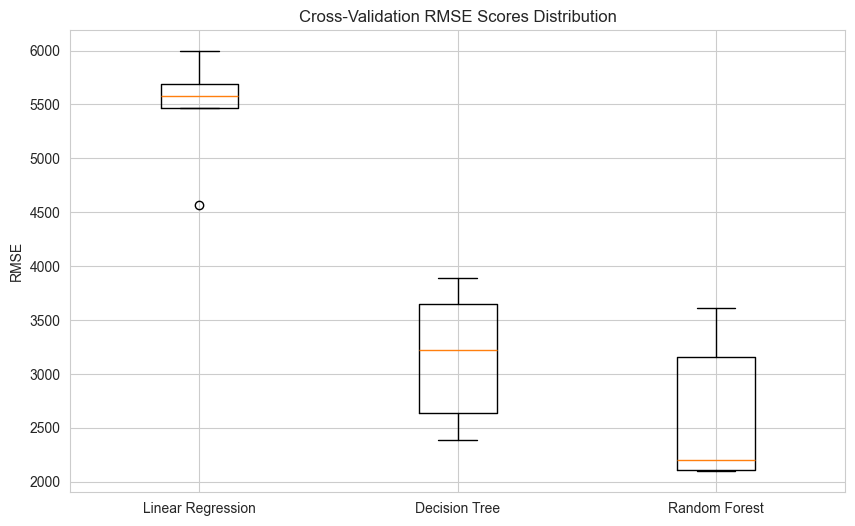

In [27]:
# Cross-Validation for Robust Model Evaluation

from sklearn.model_selection import cross_val_score, KFold

# Cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate models with cross-validation
cv_results = {}

for name, model in models.items():
    # Cross-validation scores
    cv_scores = cross_val_score(model, X_selected, y, cv=cv, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores)

    cv_results[name] = {
        'CV RMSE Mean': cv_rmse.mean(),
        'CV RMSE Std': cv_rmse.std(),
        'CV RMSE Scores': cv_rmse
    }

    print(f"{name} Cross-Validation Results:")
    print(f"  Mean RMSE: {cv_rmse.mean():.2f}")
    print(f"  Std RMSE: {cv_rmse.std():.2f}")
    print(f"  RMSE scores: {cv_rmse}")
    print()

# Compare CV results
cv_df = pd.DataFrame(cv_results).T
print("Cross-Validation Comparison:")
print(cv_df[['CV RMSE Mean', 'CV RMSE Std']])

# Box plot of CV scores
plt.figure(figsize=(10, 6))
cv_scores_data = [cv_results[name]['CV RMSE Scores'] for name in models.keys()]
plt.boxplot(cv_scores_data, labels=models.keys())
plt.title('Cross-Validation RMSE Scores Distribution')
plt.ylabel('RMSE')
plt.show()

Brand distribution:
Brand
Other       182
Realme       98
Vivo         62
Poco         60
Samsung      55
Motorola     46
Oppo         16
Google        9
OnePlus       5
Apple         5
Nokia         3
Name: count, dtype: int64

Average Price by Brand:
              mean  count      std
Brand                             
Apple     34265.00      5     0.00
Google    32731.89      9  2371.03
OnePlus   29045.80      5  3394.69
Vivo      19696.19     62  6943.70
Samsung   19131.40     55  8417.09
Oppo      16119.88     16  6684.50
Motorola  15889.98     46  8392.07
Poco      15676.33     60  7221.87
Realme    13492.55     98  5322.81
Other     12237.71    182  7569.00
Nokia      7296.00      3  2174.29


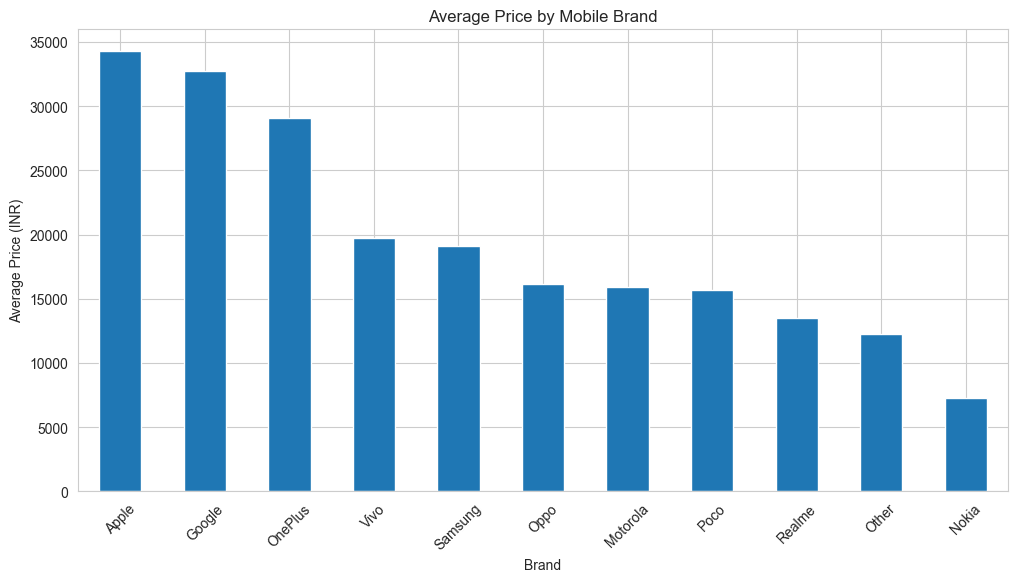


Correlation between Brand and Price: -0.022
Brand feature importance: 0.0563


In [29]:
# Feature Engineering: Extract Brand from Model

# Extract brand from model name
def extract_brand(model_name):
    brands = ['Samsung', 'Apple', 'OnePlus', 'Xiaomi', 'Oppo', 'Vivo', 'Realme', 'Poco', 'Motorola', 'Nokia', 'Google', 'Asus', 'Sony', 'LG', 'HTC']
    for brand in brands:
        if brand.lower() in model_name.lower():
            return brand
    return 'Other'

df['Brand'] = df['Model'].apply(extract_brand)

print("Brand distribution:")
print(df['Brand'].value_counts())

# Average price by brand
brand_prices = df.groupby('Brand')['Price'].agg(['mean', 'count', 'std']).round(2).sort_values('mean', ascending=False)
print("\nAverage Price by Brand:")
print(brand_prices)

# Visualize brand prices
plt.figure(figsize=(12, 6))
brand_prices['mean'].plot(kind='bar')
plt.title('Average Price by Mobile Brand')
plt.xlabel('Brand')
plt.ylabel('Average Price (INR)')
plt.xticks(rotation=45)
plt.show()

# Add brand to encoded data and check correlation
df_encoded['Brand'] = df['Brand']
le_brand = LabelEncoder()
df_encoded['Brand'] = le_brand.fit_transform(df_encoded['Brand'])

brand_corr = df_encoded[['Brand', 'Price']].corr()['Price']['Brand']
print(f"\nCorrelation between Brand and Price: {brand_corr:.3f}")

# Test if adding brand improves model
X_with_brand = df_encoded.drop('Price', axis=1)
rf_with_brand = RandomForestRegressor(n_estimators=100, random_state=42)
rf_with_brand.fit(X_with_brand, y)
brand_importance = rf_with_brand.feature_importances_[-1]  # Brand is last column
print(f"Brand feature importance: {brand_importance:.4f}")

In [30]:
# Hyperparameter Tuning Example

from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_selected, y)

print("Best parameters found:")
print(grid_search.best_params_)
print(f"Best CV score (neg MSE): {grid_search.best_score_:.4f}")
print(f"Best RMSE: {np.sqrt(-grid_search.best_score_):.2f}")

# Train best model
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)
y_pred_best = best_rf.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print(f"\nBest model performance:")
print(f"MAE: {mae_best:.2f}")
print(f"RMSE: {rmse_best:.2f}")

# Compare with original
print(f"\nImprovement over original Random Forest:")
print(f"MAE improvement: {results['Random Forest']['MAE Test'] - mae_best:.2f}")
print(f"RMSE improvement: {results['Random Forest']['RMSE Test'] - rmse_best:.2f}")

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters found:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best CV score (neg MSE): -25064783.9353
Best RMSE: 5006.47

Best model performance:
MAE: 1219.68
RMSE: 2262.95

Improvement over original Random Forest:
MAE improvement: -72.12
RMSE improvement: -130.59


In [35]:
# Prediction on New Data and Business Insights

# Example prediction for a new mobile
# Note: For demonstration, using a sample from the test set
sample_idx = 0  # First test sample
sample_features = X_test.iloc[sample_idx: sample_idx+1]
predicted_price = best_rf.predict(sample_features)[0]
actual_price = y_test.iloc[sample_idx]
print(f"Sample prediction: Predicted ₹{predicted_price:.0f}, Actual ₹{actual_price:.0f}")

# Business Insights
print("\n=== Business Insights ===")

# Price sensitivity analysis
price_elasticity = df.groupby('RAM')['Price'].mean().pct_change()
print("Price elasticity by RAM upgrade:")
print(price_elasticity.dropna().round(3))

# Most profitable segments
segment_profitability = df.groupby('RAM')['Price'].agg(['mean', 'count'])
segment_profitability['total_revenue'] = segment_profitability['mean'] * segment_profitability['count']
print("\nRevenue by RAM segment:")
print(segment_profitability.sort_values('total_revenue', ascending=False))

# Feature impact analysis
feature_impact = pd.DataFrame({
    'Feature': X_selected.columns,
    'Importance': best_rf.feature_importances_,
    'Correlation': X_selected.corrwith(y).abs()
}).sort_values('Importance', ascending=False)

print("\nFeature Impact Analysis:")
print(feature_impact.round(4))

# Recommendations for manufacturers
print("\nRecommendations:")
print("1. Focus on high RAM (8GB+) models for premium pricing")
print("2. Front camera quality significantly impacts perceived value")
print("3. Battery capacity shows diminishing returns above 5000mAh")
print("4. Consider brand positioning - premium brands command higher prices")
print("5. AI Lens feature has low impact on pricing, consider cost-benefit")

# Save enhanced model
joblib.dump(best_rf, 'mobile_price_predictor_tuned.pkl')
print("\nTuned model saved as 'mobile_price_predictor_tuned.pkl'")

Sample prediction: Predicted ₹8567, Actual ₹8499

=== Business Insights ===
Price elasticity by RAM upgrade:
RAM
3    0.109
4    0.309
6    0.479
8    0.349
Name: Price, dtype: float64

Revenue by RAM segment:
             mean  count  total_revenue
RAM                                    
8    22789.643312    157      3577974.0
4    11418.102151    186      2123767.0
6    16889.702479    121      2043654.0
3     8725.050000     40       349002.0
2     7864.702703     37       290994.0

Feature Impact Analysis:
                   Feature  Importance  Correlation
Front Camera  Front Camera      0.5009       0.6516
Battery            Battery      0.1287       0.0308
Memory              Memory      0.1222       0.6768
Model                Model      0.1111       0.0070
Processor        Processor      0.0752       0.0681
Brand                Brand      0.0619       0.0219

Recommendations:
1. Focus on high RAM (8GB+) models for premium pricing
2. Front camera quality significantly impacts p